<a href="https://colab.research.google.com/github/atikur234/BanglaOCR/blob/main/resnet18_full_ocr_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.models import resnet18
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm


In [ ]:
# ========== Paths ==========
BASE_DIR = r"D:\Varsity\Data mining\Dataset\Final_Bangla_OCR_Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR = os.path.join(BASE_DIR, "Test")
MODEL_DIR = os.path.join(BASE_DIR, "ResNet18-20epoch")
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "resnet18.pth")
CM_PATH = os.path.join(MODEL_DIR, "confusion_matrix.png")
CSV_PATH = os.path.join(MODEL_DIR, "predictions.csv")
PLOT_PATH = os.path.join(MODEL_DIR, "train_val_plot.png")

In [ ]:
# ========== Dataset ==========
class BanglaOCRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        folders = sorted(os.listdir(root_dir), key=lambda x: int(x))
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            if not os.path.isdir(folder_path):
                continue
            label = int(folder) - 1  # '001' -> 0, ..., '243' -> 242
            for file in os.listdir(folder_path):
                if file.lower().endswith('.bmp'):
                    self.samples.append((os.path.join(folder_path, file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, label, path

In [ ]:
# ========== Transforms ==========
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
# ========== Data Loaders ==========
full_train_set = BanglaOCRDataset(TRAIN_DIR, transform)
val_size = int(0.1 * len(full_train_set))
train_size = len(full_train_set) - val_size
train_set, val_set = random_split(full_train_set, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(BanglaOCRDataset(TEST_DIR, transform), batch_size=64, shuffle=False)

In [ ]:
# ========== Model ==========
def get_model(num_classes=243):
    model = resnet18(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # grayscale
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


In [ ]:
# ========== Early Stopping ==========
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.should_stop = False
        self.best_model_state = None

    def check(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model_state = model.state_dict()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [ ]:
# ========== Training ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(243).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
early_stopper = EarlyStopping()

EPOCHS = 20
train_losses, val_losses, train_accuracies = [], [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_losses.append(total_loss)
    train_accuracies.append(train_acc)


    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {total_loss:.4f} | Accuracy: {train_acc:.2f}% | Val Loss: {val_loss:.4f}")
    early_stopper.check(val_loss, model)
    if early_stopper.should_stop:
        print("🛑 Early stopping triggered.")
        break

Epoch 1: 100%|██████████| 709/709 [06:40<00:00,  1.77it/s]


Epoch 1 | Train Loss: 1639.5174 | Accuracy: 41.31% | Val Loss: 89.0410


Epoch 2: 100%|██████████| 709/709 [02:59<00:00,  3.96it/s]


Epoch 2 | Train Loss: 513.6835 | Accuracy: 74.08% | Val Loss: 52.6448


Epoch 3: 100%|██████████| 709/709 [05:59<00:00,  1.97it/s]


...

Epoch 18 | Train Loss: 123.5534 | Accuracy: 90.19% | Val Loss: 29.3425


Epoch 19: 100%|██████████| 709/709 [01:07<00:00, 10.47it/s]


Epoch 19 | Train Loss: 121.0451 | Accuracy: 90.34% | Val Loss: 28.4170


Epoch 20: 100%|██████████| 709/709 [01:07<00:00, 10.54it/s]


Epoch 20 | Train Loss: 117.7128 | Accuracy: 90.35% | Val Loss: 29.2588


In [ ]:
# ========== Save Best Model ==========
torch.save(early_stopper.best_model_state, MODEL_PATH)

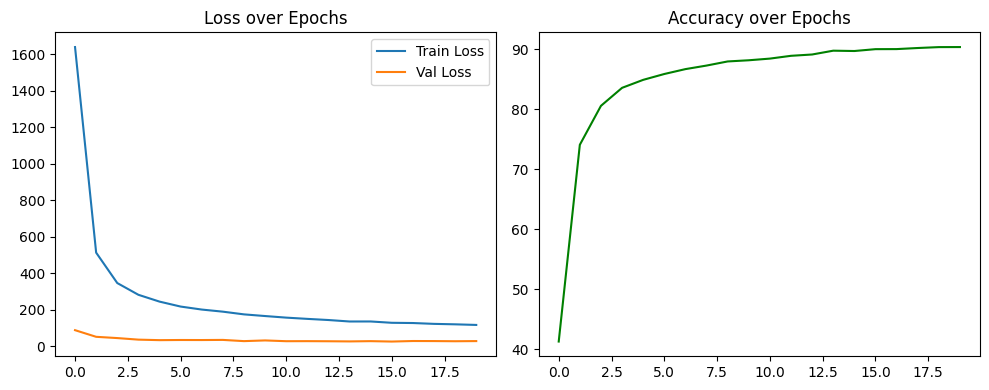

In [ ]:
# ========== Plot ==========
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy", color='green')
plt.title("Accuracy over Epochs")
plt.tight_layout()
plt.savefig(PLOT_PATH)

In [ ]:
# ========== Evaluation ==========
model.load_state_dict(early_stopper.best_model_state)
model.eval()
y_true, y_pred, image_paths = [], [], []

with torch.no_grad():
    for images, labels, paths in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())
        image_paths.extend(paths)

Testing: 100%|██████████| 188/188 [02:14<00:00,  1.40it/s]


In [ ]:
# ========== Save Report ==========
print("✅ Test Accuracy:", accuracy_score(y_true, y_pred))
print("📊 Classification Report:")
print(classification_report(y_true, y_pred))

✅ Test Accuracy: 0.8646284571809397
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        52
           1       1.00      0.98      0.99        43
           2       1.00      0.94      0.97        49
           3       0.96      0.98      0.97        53
           4       0.98      1.00      0.99        51
           5       0.98      0.96      0.97        49
           6       0.93      0.80      0.86        51
           7       1.00      0.78      0.87        49
           8       1.00      0.96      0.98        25
           9       0.90      0.95      0.92        55
          10       0.94      0.98      0.96        51
          11       0.93      1.00      0.96        26
          12       0.86      0.90      0.88        61
          13       0.88      0.96      0.92        48
          14       0.94      1.00      0.97        32
          15       0.91      1.00      0.95        52
          16       1

C:\Users\Niloy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Niloy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Niloy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

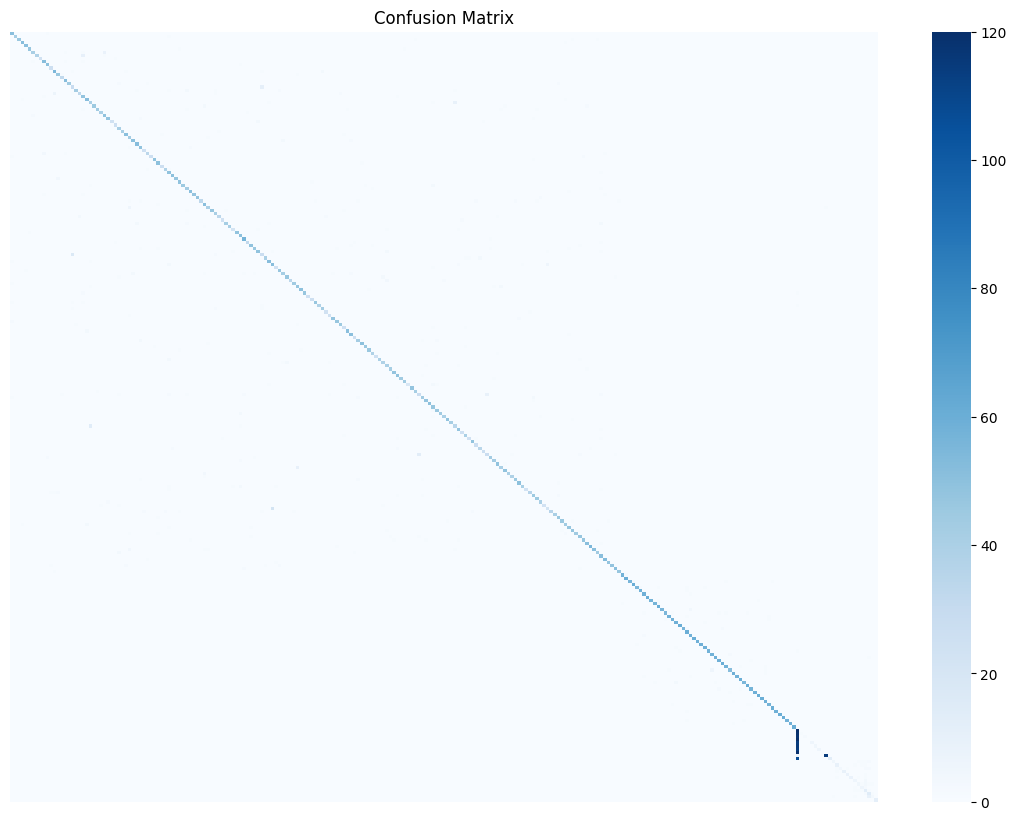

In [ ]:
# ========== Confusion Matrix ==========
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.savefig(CM_PATH)

In [ ]:
# ========== Save CSV ==========
df = pd.DataFrame({
    "image_path": image_paths,
    "actual": y_true,
    "predicted": y_pred
})
df.to_csv(CSV_PATH, index=False)
print(f"📄 Predictions saved to {CSV_PATH}")

📄 Predictions saved to D:\Varsity\Data mining\Dataset\Final_Bangla_OCR_Dataset\ResNet18-20epoch\predictions.csv
